# Laboratorio 2 - catch22 


In [182]:
from pathlib import Path

import numpy as np
import pandas as pd
import pycatch22
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

pd.set_option("display.max_columns", None)

## Cargar datos y reconstruir las series del laboratorio anterior

Se reconstruyen exactamente las mismas series de los notebooks del lab paasado: serie_obligatoria_total_mensual,
serie_pais_residencia y serie_viasde_ingreso: la serie total, los 3 países con más viajeros
y las 3 vías de ingreso.

In [183]:
ARCHIVO = Path("Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx")
if not ARCHIVO.exists():
    raise FileNotFoundError(f"No está el archivo: {ARCHIVO.resolve()}")

datos = pd.read_excel(ARCHIVO)

datos["Año"] = pd.to_numeric(datos["Año"], errors="coerce")
datos["Mes cod"] = pd.to_numeric(datos["Mes cod"], errors="coerce")
datos["Viajero"] = pd.to_numeric(datos["Viajero"], errors="coerce")
datos["Fecha"] = pd.to_datetime(
    {"year": datos["Año"], "month": datos["Mes cod"], "day": 1}, errors="coerce"
)

TIPOS_SELECCIONADOS = ["Turista", "Excursionista"]
datos_visitantes = datos[datos["Tipo de Viajero"].isin(TIPOS_SELECCIONADOS)].copy()

print("dataset:", datos.shape)

dataset: (161036, 14)


In [184]:
# --- serie_total (serie_obligatoria_total_mensual.ipynb) -------------------
serie_total = (
    datos_visitantes
    .dropna(subset=["Fecha", "Viajero"])
    .groupby("Fecha")["Viajero"]
    .sum()
    .sort_index()
    .asfreq("MS")
)
serie_total.name = "Total"

# --- series por país (serie_pais_residencia.ipynb) --------------------------
top_3_paises = (
    datos.groupby("País")["Viajero"].sum().nlargest(3).index.tolist()
)

series_paises = {}
for pais in top_3_paises:
    df_pais = datos[datos["País"] == pais]
    serie_mensual = df_pais.groupby("Fecha")["Viajero"].sum().asfreq("MS").fillna(0)
    series_paises[f"Pais_{pais}"] = serie_mensual

# --- series por vía (serie_viasde_ingreso.ipynb) -----------------------------
series_vias = (
    datos_visitantes
    .dropna(subset=["Fecha", "Vía", "Viajero"])
    .groupby(["Fecha", "Vía"])["Viajero"]
    .sum()
    .unstack("Vía")
    .sort_index()
    .asfreq("MS")
)

series_por_via = {
    "Via_Aerea": series_vias["Aérea"],
    "Via_Terrestre": series_vias["Terrestre"],
    "Via_Maritima": series_vias["Marítima"].dropna(),  # tiene huecos históricos
}

# --- diccionario final con TODAS las series del laboratorio anterior --------
todas_las_series = {"Total": serie_total, **series_paises, **series_por_via}

print("Series incluidas en el análisis catch22:")
for nombre, serie in todas_las_series.items():
    print(f"  - {nombre}: {len(serie)} observaciones "
          f"({serie.index.min().date()} a {serie.index.max().date()})")

Series incluidas en el análisis catch22:
  - Total: 210 observaciones (2009-01-01 a 2026-06-01)
  - Pais_El Salvador: 210 observaciones (2009-01-01 a 2026-06-01)
  - Pais_Guatemala: 168 observaciones (2009-01-01 a 2022-12-01)
  - Pais_Estados Unidos de América: 210 observaciones (2009-01-01 a 2026-06-01)
  - Via_Aerea: 210 observaciones (2009-01-01 a 2026-06-01)
  - Via_Terrestre: 210 observaciones (2009-01-01 a 2026-06-01)
  - Via_Maritima: 96 observaciones (2009-01-01 a 2016-12-01)


### 2.2 Extracción de las 22 características de catch22 

Cada fila de matriz_catch22 es una serie temporal, cada columna una característica de catch22.

In [185]:
filas = []
for nombre, serie in todas_las_series.items():
    serie_limpia = serie.dropna().astype(float)
    resultado = pycatch22.catch22_all(serie_limpia.to_list())
    fila = dict(zip(resultado["names"], resultado["values"]))
    fila["serie"] = nombre
    filas.append(fila)

matriz_catch22 = pd.DataFrame(filas).set_index("serie")

print('Características de catch22')
for clave, valor in filas[0].items():
    print(clave)


Características de catch22
DN_HistogramMode_5
DN_HistogramMode_10
CO_f1ecac
CO_FirstMin_ac
CO_HistogramAMI_even_2_5
CO_trev_1_num
MD_hrv_classic_pnn40
SB_BinaryStats_mean_longstretch1
SB_TransitionMatrix_3ac_sumdiagcov
PD_PeriodicityWang_th0_01
CO_Embed2_Dist_tau_d_expfit_meandiff
IN_AutoMutualInfoStats_40_gaussian_fmmi
FC_LocalSimple_mean1_tauresrat
DN_OutlierInclude_p_001_mdrmd
DN_OutlierInclude_n_001_mdrmd
SP_Summaries_welch_rect_area_5_1
SB_BinaryStats_diff_longstretch0
SB_MotifThree_quantile_hh
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1
SP_Summaries_welch_rect_centroid
FC_LocalSimple_mean3_stderr
serie


### 2.3 construcción de la matriz

In [186]:
print("Matriz catch22 (series x 22 características):", matriz_catch22.shape)
matriz_catch22

Matriz catch22 (series x 22 características): (7, 22)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,,
Total,0.082725,0.341996,8.965200,3,0.352307,-0.061859,0.933014,30.0,0.013774,11,0.318316,2.0,0.055556,0.209524,0.323810,0.820223,6.0,1.851842,0.833333,0.857143,0.122718,0.625905
Pais_El Salvador,-0.367487,-0.590398,13.873639,3,0.476428,-0.035848,0.904306,50.0,0.020833,3,0.318767,2.0,0.038462,0.728571,0.304762,0.859559,5.0,1.781165,0.857143,0.857143,0.073631,0.530967
Pais_Guatemala,-0.452735,-0.686895,8.500395,10,0.466157,0.000222,0.928144,49.0,0.020833,11,0.333742,9.0,0.052632,0.505952,0.642857,0.848429,6.0,1.728439,0.853659,0.853659,0.122718,0.562307
Pais_Estados Unidos de América,-0.628976,-0.373392,9.224247,2,0.228623,0.012101,0.923445,12.0,0.020833,5,0.280009,1.0,0.038462,0.828571,0.319048,0.723445,5.0,1.973228,0.166667,0.142857,0.098175,0.738999
Via_Aerea,-0.398224,-0.114663,6.590944,10,0.206212,-0.162779,0.956938,34.0,0.010204,11,0.209901,9.0,0.071429,0.185714,0.323810,0.758284,5.0,2.000891,0.857143,0.857143,0.171806,0.738677
Via_Terrestre,0.277301,-0.193022,9.572755,2,0.484160,-0.024702,0.933014,29.0,0.013774,3,0.335739,1.0,0.055556,0.219048,0.328571,0.817693,6.0,1.781787,0.833333,0.857143,0.098175,0.615634
Via_Maritima,-0.466415,-0.466415,1.023727,2,0.093351,-0.436318,1.000000,8.0,0.006187,3,0.077741,1.0,0.500000,-0.020833,0.437500,0.452156,4.0,2.110083,0.171429,0.657143,1.030835,1.101251


### 2.4 Estandarización de las características (necesario antes de PCA/clustering)

In [187]:
escalador = StandardScaler()
matriz_estandarizada = pd.DataFrame(
    escalador.fit_transform(matriz_catch22),
    index=matriz_catch22.index,
    columns=matriz_catch22.columns,
)

matriz_estandarizada

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,,
Total,1.187296,1.987207,0.199568,-0.454406,0.157273,0.268722,-0.239672,-0.018985,-0.264219,1.137147,0.577189,-0.454406,-0.384807,-0.584531,-0.519253,0.502659,1.020621,-0.290127,0.587797,0.529063,-0.381246,-0.425054
Pais_El Salvador,-0.289970,-0.909981,1.569457,-0.454406,1.017175,0.445882,-1.248108,1.309956,1.038756,-0.985527,0.582327,-0.454406,-0.493609,1.200349,-0.686609,0.802387,-0.408248,-0.832713,0.665509,0.529063,-0.533745,-0.955615
Pais_Guatemala,-0.569691,-1.209821,0.069846,1.569766,0.946020,0.691558,-0.410764,1.243509,1.038756,1.137147,0.753244,1.569766,-0.403418,0.434816,2.283966,0.717577,1.020621,-1.237491,0.654137,0.515003,-0.381246,-0.780470
Pais_Estados Unidos de América,-1.147986,-0.235689,0.271865,-0.743573,-0.699599,0.772470,-0.575817,-1.215032,1.038756,-0.454859,0.139970,-0.743573,-0.493609,1.544225,-0.561092,-0.234768,-0.408248,0.641756,-1.588146,-2.353266,-0.457496,0.206977
Via_Aerea,-0.390826,0.568251,-0.463060,1.569766,-0.854859,-0.418662,0.600690,0.246803,-0.923165,1.137147,-0.660193,1.569766,-0.283778,-0.666406,-0.519253,0.030694,-0.408248,0.854124,0.665509,0.529063,-0.228748,0.205176
Via_Terrestre,1.825754,0.324767,0.369130,-0.743573,1.070742,0.521798,-0.239672,-0.085432,-0.264219,-0.985527,0.776033,-0.743573,-0.384807,-0.551781,-0.477414,0.483380,1.020621,-0.827936,0.587797,0.529063,-0.457496,-0.482448
Via_Maritima,-0.614577,-0.524733,-2.016806,-0.743573,-1.636751,-2.281768,2.113343,-1.480820,-1.664663,-0.985527,-2.168570,-0.743573,2.444028,-1.376674,0.479655,-2.301929,-1.837117,1.692387,-1.572603,-0.277989,2.439977,2.231435


### Función para simplificar la generación de los gráficos

In [188]:
CARPETA_FIGURAS = Path("figurasLab2")
CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)

TIPOS_VIAJERO_VALIDOS = ["Turista", "Excursionista"]
N_PAISES_TOP = 3

def guardar_figura(nombre_archivo, mostrar=True):
    ruta = CARPETA_FIGURAS / nombre_archivo
    plt.tight_layout()
    plt.savefig(ruta, dpi=150)
    print(f"  [figura guardada] {ruta}")
    
    if mostrar:
        plt.show()   # Muestra la figura en Jupyter (y limpia la memoria)
    else:
        plt.close()  # Solo borra la figura de memoria sin mostrarla

## 2.5 Con la matriz obtenida, se realizaron los sigueintes análisis




### PCA

Ejecuta PCA sobre la matriz estandarizada y devuelve:
df_componentes: coordenadas de cada serie en cada componente
varianza_explicada / varianza_acumulada
df_cargas: loadings de cada caracteristica en cada componente
importancia_caracteristicas: ranking de caracteristicas mas influyentes


Varianza explicada por componente (PCA):
  PC1: 0.544  (acumulada: 0.544)
  PC2: 0.179  (acumulada: 0.723)
  PC3: 0.141  (acumulada: 0.864)
  PC4: 0.080  (acumulada: 0.944)
  PC5: 0.044  (acumulada: 0.988)
  PC6: 0.012  (acumulada: 1.000)
  PC7: 0.000  (acumulada: 1.000)
  [figura guardada] figurasLab2\pca_dispersión_series.png


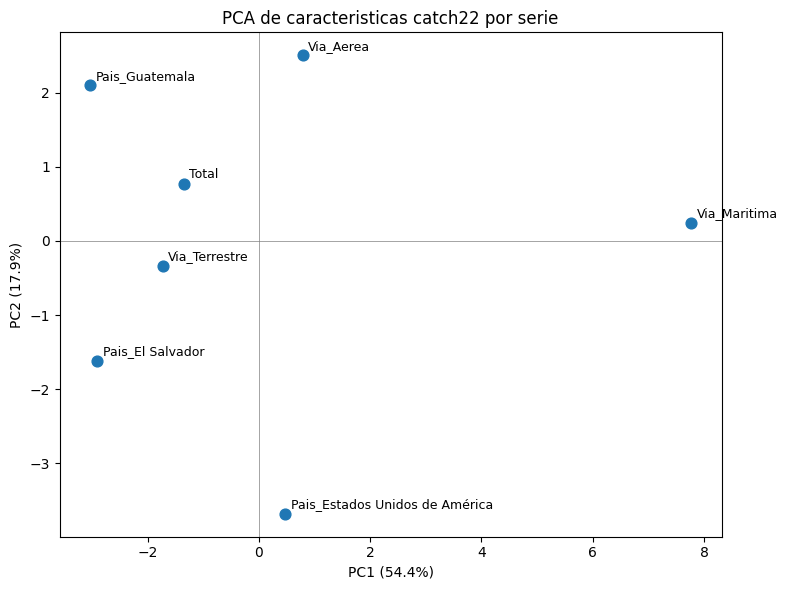

  [figura guardada] figurasLab2\pca_cargas_pc1_pc2.png


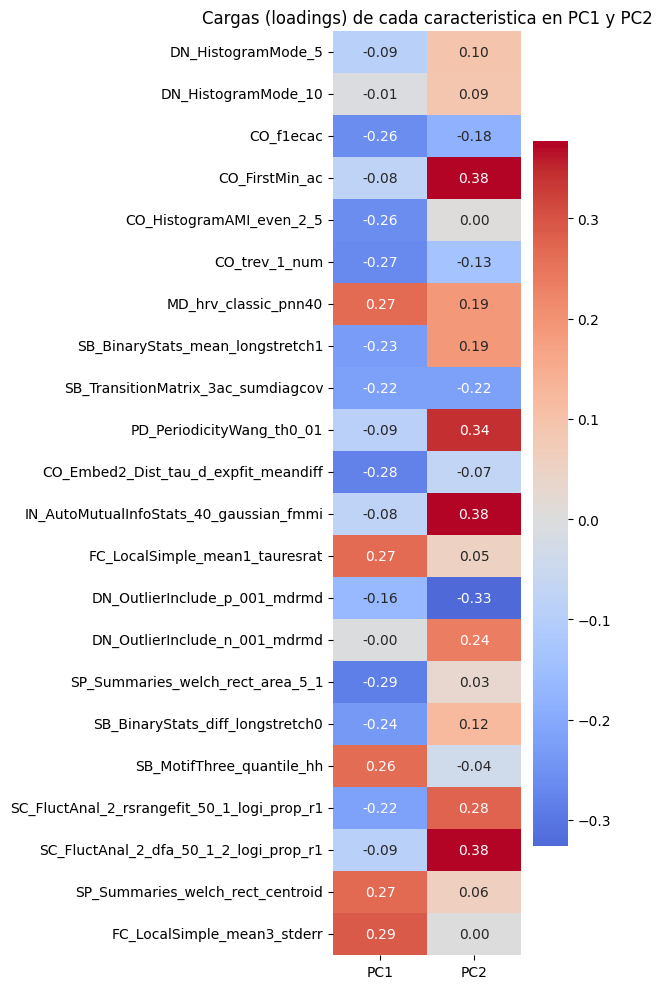


Caracteristicas mas importantes usando los primeros 4 componentes (94.4% de varianza acumulada):
SB_TransitionMatrix_3ac_sumdiagcov             0.197520
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1    0.193770
SB_BinaryStats_mean_longstretch1               0.192470
DN_OutlierInclude_p_001_mdrmd                  0.191373
CO_trev_1_num                                  0.185595
dtype: float64
  [figura guardada] figurasLab2\pca_importancia_caracteristicas.png


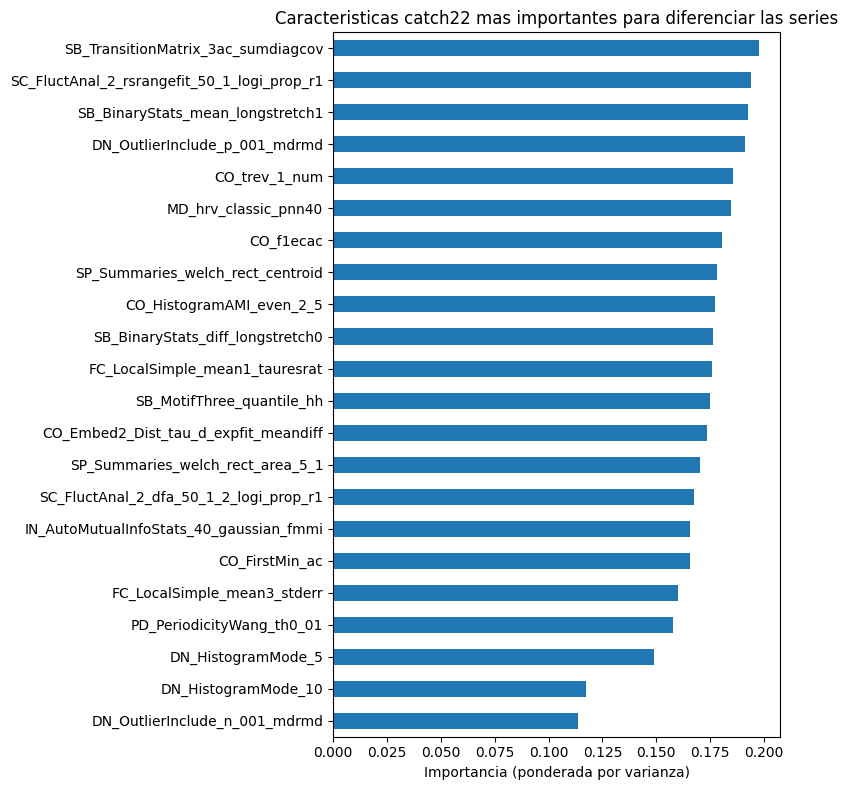

SB_TransitionMatrix_3ac_sumdiagcov             0.197520
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1    0.193770
SB_BinaryStats_mean_longstretch1               0.192470
DN_OutlierInclude_p_001_mdrmd                  0.191373
CO_trev_1_num                                  0.185595
MD_hrv_classic_pnn40                           0.184592
CO_f1ecac                                      0.180287
SP_Summaries_welch_rect_centroid               0.178034
CO_HistogramAMI_even_2_5                       0.177018
SB_BinaryStats_diff_longstretch0               0.176481
FC_LocalSimple_mean1_tauresrat                 0.175757
SB_MotifThree_quantile_hh                      0.175055
CO_Embed2_Dist_tau_d_expfit_meandiff           0.173395
SP_Summaries_welch_rect_area_5_1               0.170176
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1         0.167360
IN_AutoMutualInfoStats_40_gaussian_fmmi        0.165634
CO_FirstMin_ac                                 0.165634
FC_LocalSimple_mean3_stderr                    0

In [189]:
modelo_pca = PCA()

coordenadas = modelo_pca.fit_transform(matriz_estandarizada)

varianza_explicada = modelo_pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

df_componentes = pd.DataFrame(
    coordenadas,
    index=matriz_estandarizada.index,
    columns=[f"PC{i + 1}" for i in range(coordenadas.shape[1])],
)

print("\nVarianza explicada por componente (PCA):")
for i, (v, va) in enumerate(zip(varianza_explicada, varianza_acumulada), start=1):
    print(f"  PC{i}: {v:.3f}  (acumulada: {va:.3f})")

# --- dispersion PC1 vs PC2 ----------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(df_componentes["PC1"], df_componentes["PC2"], s=60)
for nombre, fila in df_componentes.iterrows():
    plt.annotate(nombre, (fila["PC1"], fila["PC2"]), fontsize=9, xytext=(4, 4),
                    textcoords="offset points")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.xlabel(f"PC1 ({varianza_explicada[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({varianza_explicada[1] * 100:.1f}%)")
plt.title("PCA de caracteristicas catch22 por serie")
guardar_figura("pca_dispersión_series.png")

# --- cargas (loadings) de PC1/PC2 ---------------------------------------
df_cargas = pd.DataFrame(
    modelo_pca.components_.T,
    index=matriz_estandarizada.columns,
    columns=[f"PC{i + 1}" for i in range(modelo_pca.components_.shape[0])],
)

plt.figure(figsize=(6, 10))
sns.heatmap(df_cargas.iloc[:, :2], annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Cargas (loadings) de cada caracteristica en PC1 y PC2")
guardar_figura("pca_cargas_pc1_pc2.png")

# --- importancia de caracteristicas (ponderada por varianza) ------------
n_componentes_90 = int(np.argmax(varianza_acumulada >= 0.90)) + 1
pesos = varianza_explicada[:n_componentes_90]
importancia = (df_cargas.iloc[:, :n_componentes_90].abs().values * pesos).sum(axis=1)
importancia_caracteristicas = (
    pd.Series(importancia, index=df_cargas.index).sort_values(ascending=False)
)

print(f"\nCaracteristicas mas importantes usando los primeros {n_componentes_90} "
        f"componentes ({varianza_acumulada[n_componentes_90 - 1] * 100:.1f}% de varianza acumulada):")
print(importancia_caracteristicas.head(5))

plt.figure(figsize=(8, 8))
importancia_caracteristicas.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importancia (ponderada por varianza)")
plt.title("Caracteristicas catch22 mas importantes para diferenciar las series")
guardar_figura("pca_importancia_caracteristicas.png")

df_componentes
varianza_explicada
df_cargas
importancia_caracteristicas

### Clustering


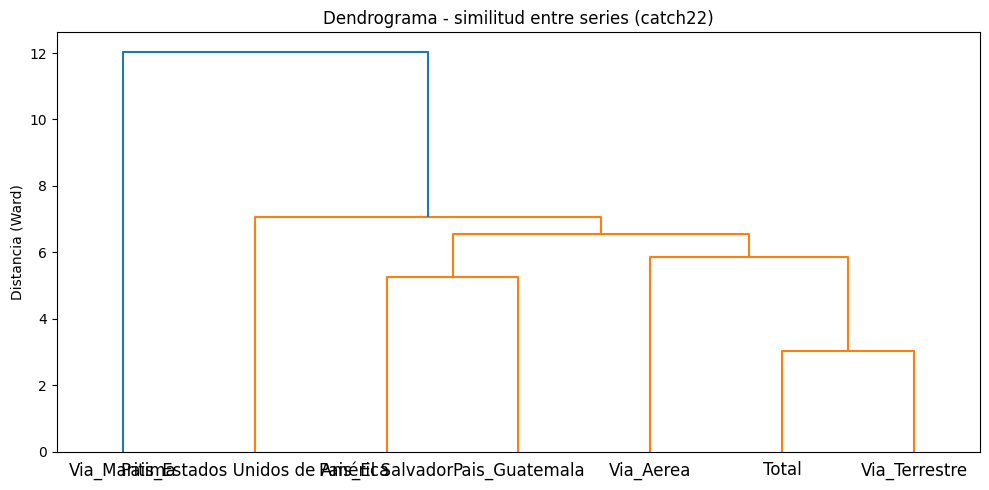

In [190]:
enlace = linkage(matriz_estandarizada, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(enlace, labels=matriz_estandarizada.index.tolist())
plt.title("Dendrograma - similitud entre series (catch22)")
plt.ylabel("Distancia (Ward)")
plt.tight_layout()
plt.show()

In [191]:
# Número de clusters: se prueba con silhouette 
n_series = matriz_estandarizada.shape[0]
mejores_k, mejor_score = None, -1
for k in range(2, n_series):
    etiquetas_k = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(
        matriz_estandarizada
    )
    score = silhouette_score(matriz_estandarizada, etiquetas_k)
    print(f"k={k} -> silhouette={score:.3f}")
    if score > mejor_score:
        mejor_score, mejores_k = score, k

print(f"\nMejor número de clusters según silhouette: k={mejores_k} (score={mejor_score:.3f})")

clustering_final = AgglomerativeClustering(n_clusters=mejores_k, linkage="ward")
etiquetas = clustering_final.fit_predict(matriz_estandarizada)

resultado_clusters = pd.DataFrame({
    "serie": matriz_estandarizada.index,
    "cluster": etiquetas,
}).sort_values("cluster")

resultado_clusters

k=2 -> silhouette=0.358
k=3 -> silhouette=0.126
k=4 -> silhouette=0.102
k=5 -> silhouette=0.106
k=6 -> silhouette=0.090

Mejor número de clusters según silhouette: k=2 (score=0.358)


,serie,cluster
0,Total,0
1,Pais_El Salvador,0
2,Pais_Guatemala,0
3,Pais_Estados Unidos de América,0
4,Via_Aerea,0
5,Via_Terrestre,0
6,Via_Maritima,1


### Mapa de calor (Heatmap) de las características

  [figura guardada] figurasLab2\heatmap_caracteristicas_por_serie.png


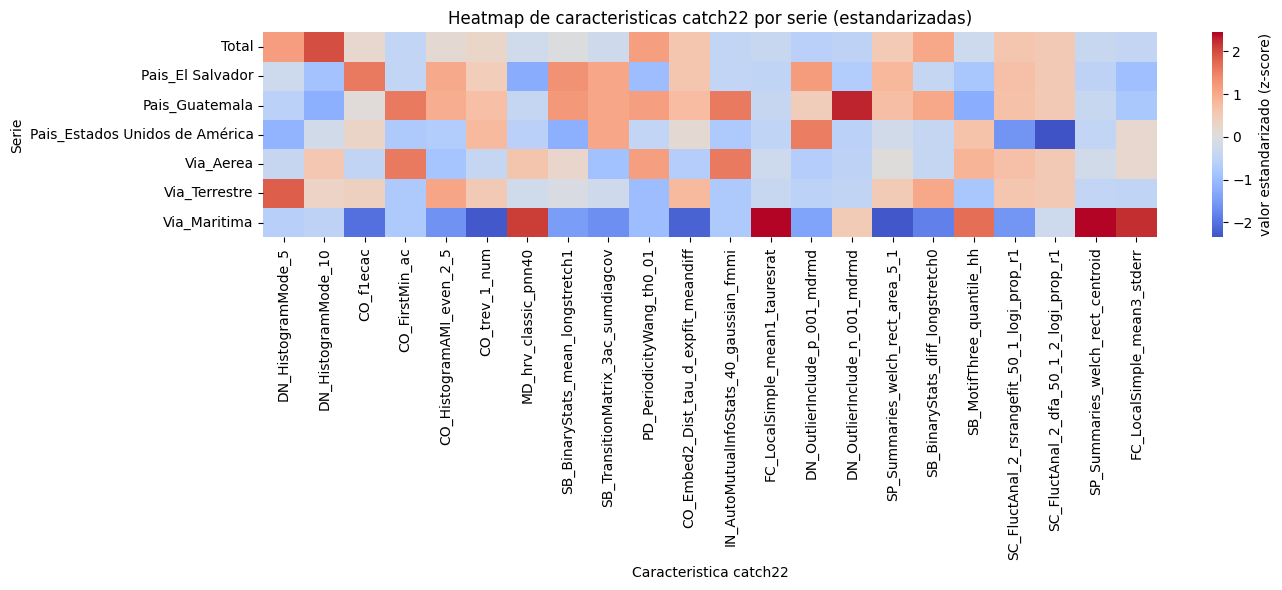

In [192]:
plt.figure(figsize=(14, 6))
sns.heatmap(
    matriz_estandarizada, cmap="coolwarm", center=0, annot=False,
    cbar_kws={"label": "valor estandarizado (z-score)"},
)
plt.title("Heatmap de caracteristicas catch22 por serie (estandarizadas)")
plt.xlabel("Caracteristica catch22")
plt.ylabel("Serie")
guardar_figura("heatmap_caracteristicas_por_serie.png")

### Matriz de correlacion entre caracteristicas

Calcula y grafica la correlacion entre las 22 caracteristicas catch22 (a traves de las series). Util para detectar redundancia entre caracteristicas antes de interpretar el PCA.

  [figura guardada] figurasLab2\matriz_correlacion_caracteristicas.png


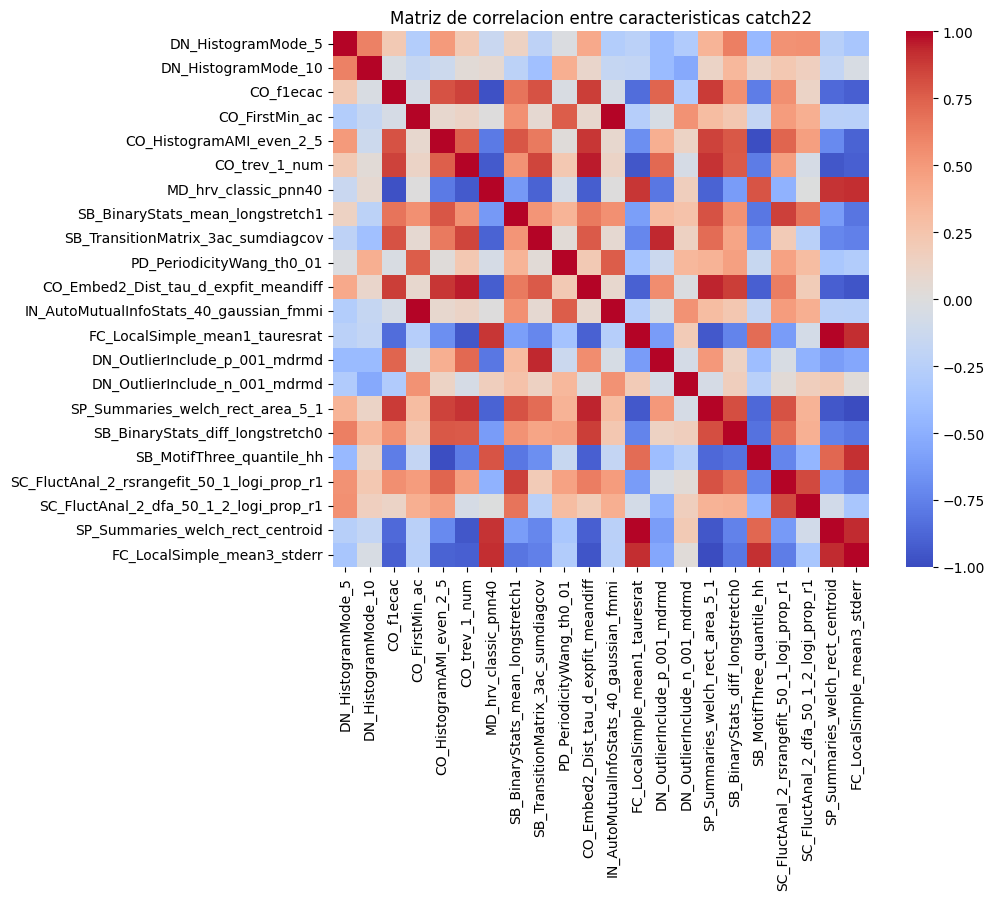


Pares de caracteristicas catch22 mas correlacionadas (posible redundancia):
  IN_AutoMutualInfoStats_40_gaussian_fmmi  <->  CO_FirstMin_ac:  r = 1.00
  FC_LocalSimple_mean1_tauresrat  <->  SP_Summaries_welch_rect_centroid:  r = 1.00
  FC_LocalSimple_mean3_stderr  <->  SP_Summaries_welch_rect_area_5_1:  r = -0.99


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
DN_HistogramMode_5,1.000000,0.610915,0.217766,-0.280361,0.492985,0.203946,-0.142681,0.134525,-0.213957,-0.018260,0.419179,-0.280361,-0.230138,-0.423347,-0.291133,0.358586,0.624199,-0.431467,0.533569,0.544697,-0.257274,-0.336136
DN_HistogramMode_10,0.610915,1.000000,-0.037877,-0.167524,-0.124554,0.034059,0.063815,-0.222611,-0.386962,0.390182,0.098229,-0.167524,-0.182830,-0.425626,-0.534259,0.119750,0.332087,0.122217,0.219952,0.159976,-0.180250,-0.041519
CO_f1ecac,0.217766,-0.037877,1.000000,-0.056870,0.799397,0.857156,-0.974392,0.664195,0.802823,-0.038111,0.869363,-0.056870,-0.850519,0.728404,-0.296771,0.878955,0.542021,-0.770159,0.550880,0.120440,-0.864099,-0.908048
CO_FirstMin_ac,-0.280361,-0.167524,-0.056870,1.000000,0.078643,0.119706,0.001307,0.545843,0.070196,0.757865,0.078651,1.000000,-0.263389,-0.051096,0.533383,0.301197,0.227672,-0.173078,0.487886,0.388751,-0.239387,-0.247156
CO_HistogramAMI_even_2_5,0.492985,-0.124554,0.799397,0.078643,1.000000,0.751558,-0.788877,0.782452,0.643131,0.022298,0.891783,0.078643,-0.681232,0.384597,0.131539,0.856761,0.777873,-0.985569,0.733386,0.474874,-0.704489,-0.895185
CO_trev_1_num,0.203946,0.034059,0.857156,0.119706,0.751558,1.000000,-0.935498,0.533050,0.851418,0.222801,0.953327,0.119706,-0.948924,0.714862,-0.060828,0.899941,0.768292,-0.780079,0.470954,-0.056390,-0.952558,-0.907061
MD_hrv_classic_pnn40,-0.142681,0.063815,-0.974392,0.001307,-0.788877,-0.935498,1.000000,-0.628903,-0.895312,-0.058738,-0.917235,0.001307,0.892154,-0.800473,0.168931,-0.891956,-0.613077,0.790818,-0.484326,-0.005730,0.900905,0.921523
SB_BinaryStats_mean_longstretch1,0.134525,-0.222611,0.664195,0.545843,0.782452,0.533050,-0.628903,1.000000,0.522160,0.354053,0.642927,0.545843,-0.599647,0.309884,0.262094,0.799162,0.534787,-0.804069,0.863782,0.668534,-0.605813,-0.811178
SB_TransitionMatrix_3ac_sumdiagcov,-0.213957,-0.386962,0.802823,0.070196,0.643131,0.851418,-0.895312,0.522160,1.000000,0.033678,0.770655,0.070196,-0.721099,0.929964,0.145808,0.696868,0.443966,-0.684878,0.201994,-0.237882,-0.722091,-0.750370
PD_PeriodicityWang_th0_01,-0.018260,0.390182,-0.038111,0.757865,0.022298,0.222801,-0.058738,0.354053,0.033678,1.000000,0.213854,0.757865,-0.362494,-0.130412,0.335136,0.361533,0.464238,-0.155578,0.458015,0.298634,-0.335266,-0.287654


In [193]:
matriz_caracteristicas = matriz_estandarizada
matriz_correlacion = matriz_caracteristicas.corr()
 
plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_correlacion, cmap="coolwarm", center=0, annot=False,
    vmin=-1, vmax=1, square=True,
)
plt.title("Matriz de correlacion entre caracteristicas catch22")
guardar_figura("matriz_correlacion_caracteristicas.png")

# pares de caracteristicas mas redundantes (|correlacion| mas alta, excluyendo diagonal)
correlaciones_apiladas = (
    matriz_correlacion.where(~np.eye(len(matriz_correlacion), dtype=bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
)
pares_top = correlaciones_apiladas.head(5)

print("\nPares de caracteristicas catch22 mas correlacionadas (posible redundancia):")
vistos = set()
for (feat_a, feat_b), valor in pares_top.items():
    clave = tuple(sorted([feat_a, feat_b]))
    if clave in vistos:
        continue
    vistos.add(clave)
    print(f"  {feat_a}  <->  {feat_b}:  r = {matriz_correlacion.loc[feat_a, feat_b]:.2f}")

matriz_correlacion

### Mapa de distancias entre series

  [figura guardada] figurasLab2\mapa_distancias_series.png


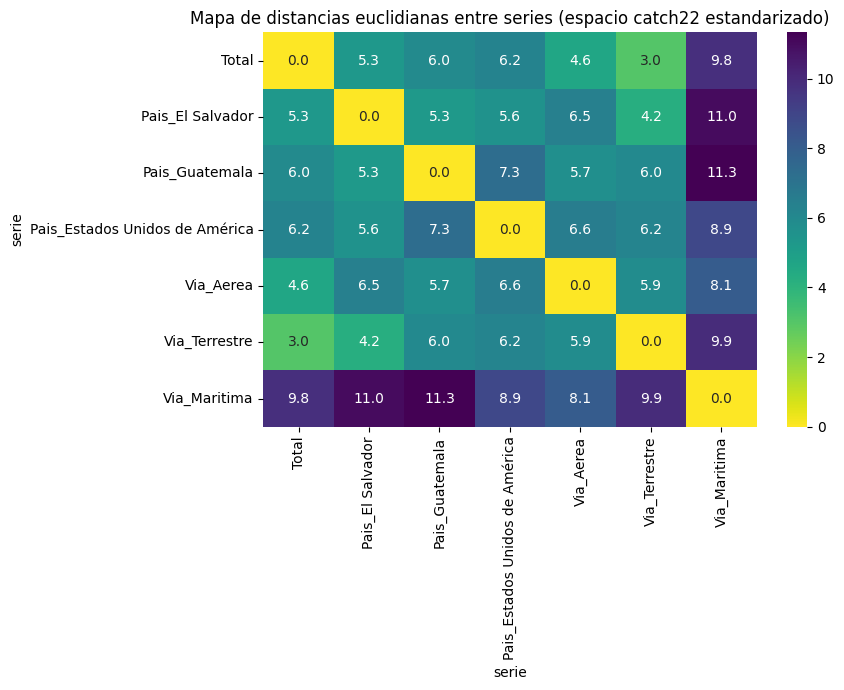

serie,Total,Pais_El Salvador,Pais_Guatemala,Pais_Estados Unidos de América,Via_Aerea,Via_Terrestre,Via_Maritima
serie,,,,,,,
Total,0.000000,5.307759,5.970279,6.242520,4.625335,3.019444,9.796160
Pais_El Salvador,5.307759,0.000000,5.253848,5.615035,6.454319,4.221565,11.003440
Pais_Guatemala,5.970279,5.253848,0.000000,7.333024,5.725830,5.987508,11.327646
Pais_Estados Unidos de América,6.242520,5.615035,7.333024,0.000000,6.552714,6.227672,8.859929
Via_Aerea,4.625335,6.454319,5.725830,6.552714,0.000000,5.866176,8.066286
Via_Terrestre,3.019444,4.221565,5.987508,6.227672,5.866176,0.000000,9.931281
Via_Maritima,9.796160,11.003440,11.327646,8.859929,8.066286,9.931281,0.000000


In [194]:
distancias = squareform(pdist(matriz_estandarizada, metric="euclidean"))
df_distancias = pd.DataFrame(
    distancias, index=matriz_estandarizada.index, columns=matriz_estandarizada.index
)

plt.figure(figsize=(9, 7))
sns.heatmap(df_distancias, annot=True, fmt=".1f", cmap="viridis_r")
plt.title("Mapa de distancias euclidianas entre series (espacio catch22 estandarizado)")
guardar_figura("mapa_distancias_series.png")

df_distancias

## 2.6 Responda las siguientes preguntas

## 2.7 Interpretacion: ¿que series son mas similares?

Cruza los tres resultados (distancias, clustering, PCA) para identificar y justificar cual es el par de series con comportamiento mas similar.

In [195]:
distancias_sin_diagonal = df_distancias.where(~np.eye(len(df_distancias), dtype=bool))
par_mas_cercano = distancias_sin_diagonal.stack().idxmin()
distancia_minima = distancias_sin_diagonal.stack().min()

serie_a, serie_b = par_mas_cercano
cluster_a = resultado_clusters.set_index("serie").loc[serie_a, "cluster"]
cluster_b = resultado_clusters.set_index("serie").loc[serie_b, "cluster"]


print(
    f"El par de series con menor distancia euclidiana en el espacio catch22 "
    f"estandarizado es:\n  -> {serie_a}  <->  {serie_b}  (distancia = {distancia_minima:.2f})"
)
if cluster_a == cluster_b:
    print(
        f"Esto es consistente con el clustering jerarquico: ambas series quedaron "
        f"asignadas al mismo cluster (cluster {cluster_a})."
    )
else:
    print(
        f"En el clustering jerarquico quedaron en clusters distintos "
        f"({cluster_a} y {cluster_b}), aunque su distancia directa es la menor de todas."
    )

dist_pc = np.sqrt(
    (df_componentes.loc[serie_a, "PC1"] - df_componentes.loc[serie_b, "PC1"]) ** 2
    + (df_componentes.loc[serie_a, "PC2"] - df_componentes.loc[serie_b, "PC2"]) ** 2
)
print(
    f"En el plano PC1-PC2 del PCA, la distancia entre estas dos series es {dist_pc:.2f}, "
    f"lo que tambien refleja su cercania visual en el grafico de dispersion."
)

print("\nResumen de clusters encontrados:")
for cluster_id, grupo in resultado_clusters.groupby("cluster"):
    print(f"  Cluster {cluster_id}: {', '.join(grupo['serie'].tolist())}")

El par de series con menor distancia euclidiana en el espacio catch22 estandarizado es:
  -> Total  <->  Via_Terrestre  (distancia = 3.02)
Esto es consistente con el clustering jerarquico: ambas series quedaron asignadas al mismo cluster (cluster 0).
En el plano PC1-PC2 del PCA, la distancia entre estas dos series es 1.17, lo que tambien refleja su cercania visual en el grafico de dispersion.

Resumen de clusters encontrados:
  Cluster 0: Total, Pais_El Salvador, Pais_Guatemala, Pais_Estados Unidos de América, Via_Aerea, Via_Terrestre
  Cluster 1: Via_Maritima


## 2.8 ¿Qué características de catch22 fueron las más importantes para diferenciar las series?

In [196]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=matriz_estandarizada.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
)

# componentes que explican el 90% de la varianza
n_componentes_90 = int(np.argmax(varianza_acumulada >= 0.90)) + 1
pesos = varianza_explicada[:n_componentes_90]

importancia = (
    loadings.iloc[:, :n_componentes_90].abs().values * pesos
).sum(axis=1)

importancia_features = (
    pd.Series(importancia, index=loadings.index)
    .sort_values(ascending=False)
)

print(f"Usando los primeros {n_componentes_90} componentes "
      f"({varianza_acumulada[n_componentes_90-1]*100:.1f}% de varianza acumulada):")
importancia_features

Usando los primeros 4 componentes (94.4% de varianza acumulada):


SB_TransitionMatrix_3ac_sumdiagcov             0.197520
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1    0.193770
SB_BinaryStats_mean_longstretch1               0.192470
DN_OutlierInclude_p_001_mdrmd                  0.191373
CO_trev_1_num                                  0.185595
MD_hrv_classic_pnn40                           0.184592
CO_f1ecac                                      0.180287
SP_Summaries_welch_rect_centroid               0.178034
CO_HistogramAMI_even_2_5                       0.177018
SB_BinaryStats_diff_longstretch0               0.176481
FC_LocalSimple_mean1_tauresrat                 0.175757
SB_MotifThree_quantile_hh                      0.175055
CO_Embed2_Dist_tau_d_expfit_meandiff           0.173395
SP_Summaries_welch_rect_area_5_1               0.170176
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1         0.167360
IN_AutoMutualInfoStats_40_gaussian_fmmi        0.165634
CO_FirstMin_ac                                 0.165634
FC_LocalSimple_mean3_stderr                    0

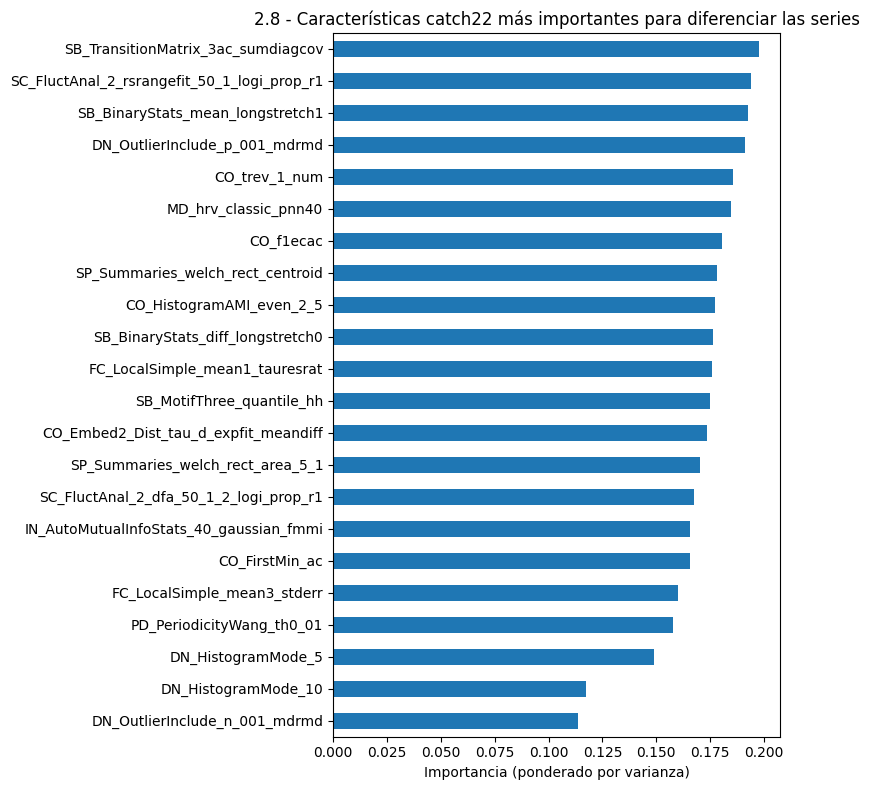

In [197]:
plt.figure(figsize=(8, 8))
importancia_features.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importancia (ponderado por varianza)")
plt.title("2.8 - Características catch22 más importantes para diferenciar las series")
plt.tight_layout()
plt.show()

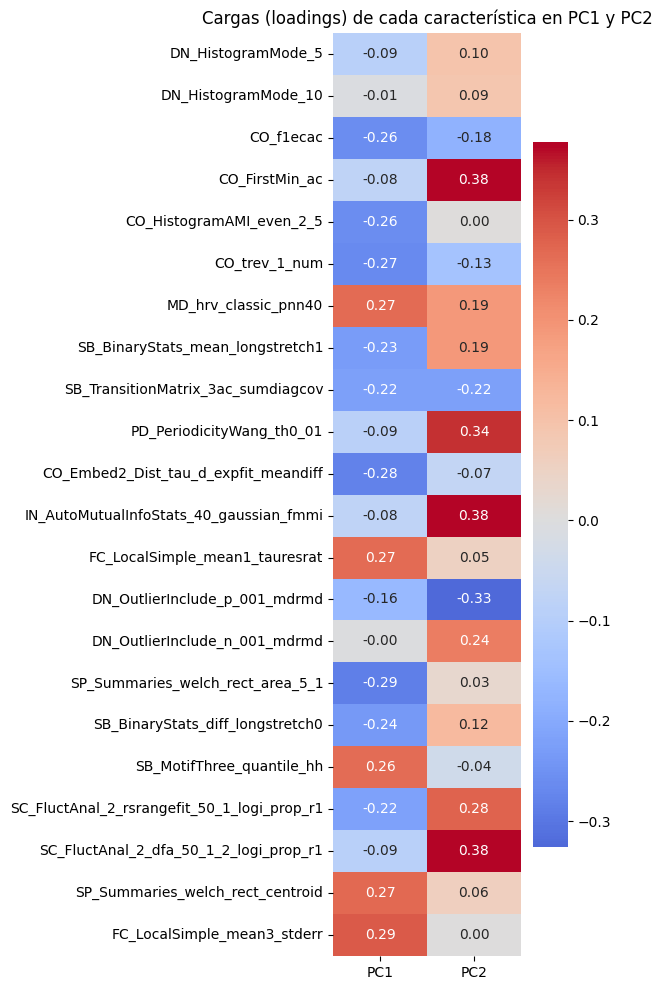

In [198]:
plt.figure(figsize=(6, 10))
sns.heatmap(loadings.iloc[:, :2], annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Cargas (loadings) de cada característica en PC1 y PC2")
plt.tight_layout()
plt.show()

## 2.9 ¿Existen grupos naturales de series? ¿Qué tienen en común?


In [199]:
categoria_original = {}
for nombre in todas_las_series:
    if nombre == "Total":
        categoria_original[nombre] = "Total"
    elif nombre.startswith("Pais_"):
        categoria_original[nombre] = "País"
    elif nombre.startswith("Via_"):
        categoria_original[nombre] = "Vía de ingreso"

resultado_clusters["categoria_original"] = resultado_clusters["serie"].map(categoria_original)

print("Grupos naturales encontrados:")
for cluster_id, grupo in resultado_clusters.groupby("cluster"):
    print(f"\nCluster {cluster_id}:")
    print(grupo[["serie", "categoria_original"]].to_string(index=False))

    series_del_cluster = grupo["serie"].tolist()
    top_features = importancia_features.head(5).index.tolist()
    print("  Promedio (estandarizado) de las 5 características más importantes:")
    print(matriz_estandarizada.loc[series_del_cluster, top_features].mean().round(2))

Grupos naturales encontrados:

Cluster 0:
                         serie categoria_original
                         Total              Total
              Pais_El Salvador               País
                Pais_Guatemala               País
Pais_Estados Unidos de América               País
                     Via_Aerea     Vía de ingreso
                 Via_Terrestre     Vía de ingreso
  Promedio (estandarizado) de las 5 características más importantes:
SB_TransitionMatrix_3ac_sumdiagcov             0.28
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1    0.26
SB_BinaryStats_mean_longstretch1               0.25
DN_OutlierInclude_p_001_mdrmd                  0.23
CO_trev_1_num                                  0.38
dtype: float64

Cluster 1:
       serie categoria_original
Via_Maritima     Vía de ingreso
  Promedio (estandarizado) de las 5 características más importantes:
SB_TransitionMatrix_3ac_sumdiagcov            -1.66
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1   -1.57
SB_BinaryStats_